# Publication Figures

This notebook reproduces the figures presented in the paper *Enriching Dimensionality Reduction with Distortion Cues*. It loads the results generated by the analysis notebooks and produces the publication-quality visualizations used throughout the manuscript and supplementary material.

> **Prerequisite**
>
> Before running this notebook, execute:
>
> 1. `main_projection_analysis.ipynb`
> 2. `sensitivity_and_ranks_shift_analysis.ipynb`
>
> These notebooks generate the data required for the figures.

## Workflow

The repository is organized into three complementary notebooks:

- **`main_projection_analysis.ipynb`** implements the proposed distortion cue methodology.
- **`sensitivity_and_ranks_shift_analysis.ipynb`** reproduces the robustness and sensitivity experiments presented in the supplementary material.
- **`plots.ipynb`** generates the publication-quality figures from the previously computed results.

In [1]:
%reset -f

## Import Dependencies

Import the required libraries together with the visualization utilities used to generate the figures.

In [2]:
from distortion_cues import visualizer, utility
import os
import numpy as np
from distortion_cues import config as cfg


Select the dataset and method for plot

In [ ]:
# dataset = 'cube_diff_size_diff_dist' # "cube_diff_size_diff_dist", "cube_diff_size_same_dist","cube_same_size_diff_dist", "tetrahedron_eq_1_close", "tetrahedron_eq_2_close" 

dataset = 'mnist'
method = 'tsne'  # tsne or umap


## Figure Configuration

Configure the input and output directories together with the plotting parameters used throughout the visualization pipeline.

In [4]:
colors = cfg.CUSTOM_COLORS

In [5]:
figsize = cfg.FIGSIZE
data_point_size= cfg.SCATTER_POINT_SIZE
linewidths = cfg.LINE_WIDTH
dpi = cfg.DPI
bscatter_plot = cfg.SCATTER_PLOT
save_format = cfg.SAVE_FORMAT


In [6]:
cfg_dt = cfg.get_config(dataset, method)

In [7]:
class_names = cfg_dt["class_names"]
colors = cfg_dt["colors"]
fontsize = cfg_dt["fontsize"]
border_thickness = cfg_dt["border_thickness"]
legend_dt_point_size = cfg_dt["legend_dt_point_size"]
legend_font_size = cfg_dt["legend_font_size"]

perplexity = cfg_dt["perplexity"]
data_point_size = cfg_dt["data_point_size"]
linewidths = cfg_dt["linewidths"]
colormap = colors

In [8]:
output_folder = f"results/{dataset}/{method}_perp_{perplexity}_plots"
output_plot_folder = f"results/{dataset}/{method}_perp_{perplexity}_plots/figures"
os.makedirs(output_plot_folder, exist_ok=True)



## Load Data

Load the projection results, distortion cues, and robustness analysis generated by the previous experiments.

In [9]:
D = utility.load_numpy_array(output_folder, "D", dataset)
class_label = utility.load_numpy_array(output_folder, "class_label", dataset)


## 3D Visualization

Only for synthetic 3D Cubic data

In [10]:
visualizer.plotly_3d_cubes_custom_colormap(D, class_label, custom_colors= colormap, filename = f"{dataset}" ,output_path=output_plot_folder)

Saved to: results/mnist/umap_perp_10_plots/figures\3D_mnist.html


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\dr-distortion-cues-A4yH4whe-py3.12\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




## Pairwise Distance Matrix Visualization

In [11]:
distance_matrix_hd_true = utility.load_numpy_array(output_folder, "distance_matrix_hd_true", dataset)
mean_cluster_distance__hd_true = utility.load_numpy_array(output_folder, "mean_cluster_distance__hd_true", dataset)

In [12]:
visualizer.plot_pairwise_cluster_distance_v2_custom_color(distance_matrix=distance_matrix_hd_true, mean_cluster_distance =mean_cluster_distance__hd_true, label=class_label, filename=f"{dataset}_true_label_{method}", border_thickness= border_thickness, fontsize=fontsize, color_list=colormap, figsize= figsize, output_path=output_plot_folder, save_format=save_format)

## Projection Visualization

Generate the low-dimensional projection together with the proposed distortion cues for qualitative analysis.

In [13]:
low_dm_emb = utility.load_numpy_array(output_folder, "low_dm_emb", dataset)

In [14]:
visualizer.plot_projection_custom_color(embedding=low_dm_emb, class_label = class_label, filename= f"{dataset}_true_label_{method}", color_list = colormap, figsize= figsize, data_point_size= data_point_size, linewidths=linewidths, legend_dt_point_size = legend_dt_point_size, legend_font_size = legend_font_size, class_names=class_names, output_path=output_plot_folder, dpi=dpi, save_format=save_format) 

## Plot CheckViz paper

Using *visualizer* utility plot the  vornoi diagram using **CheckVIZ paper Implementation**

- Splits space into Voronoi regions and then colored them by distortion metrics intensity value on that point.

In [15]:
nlm = utility.load_numpy_array(output_folder, "nlm", dataset, ext="npy")
cca = utility.load_numpy_array(output_folder, "cca", dataset, ext="npy")

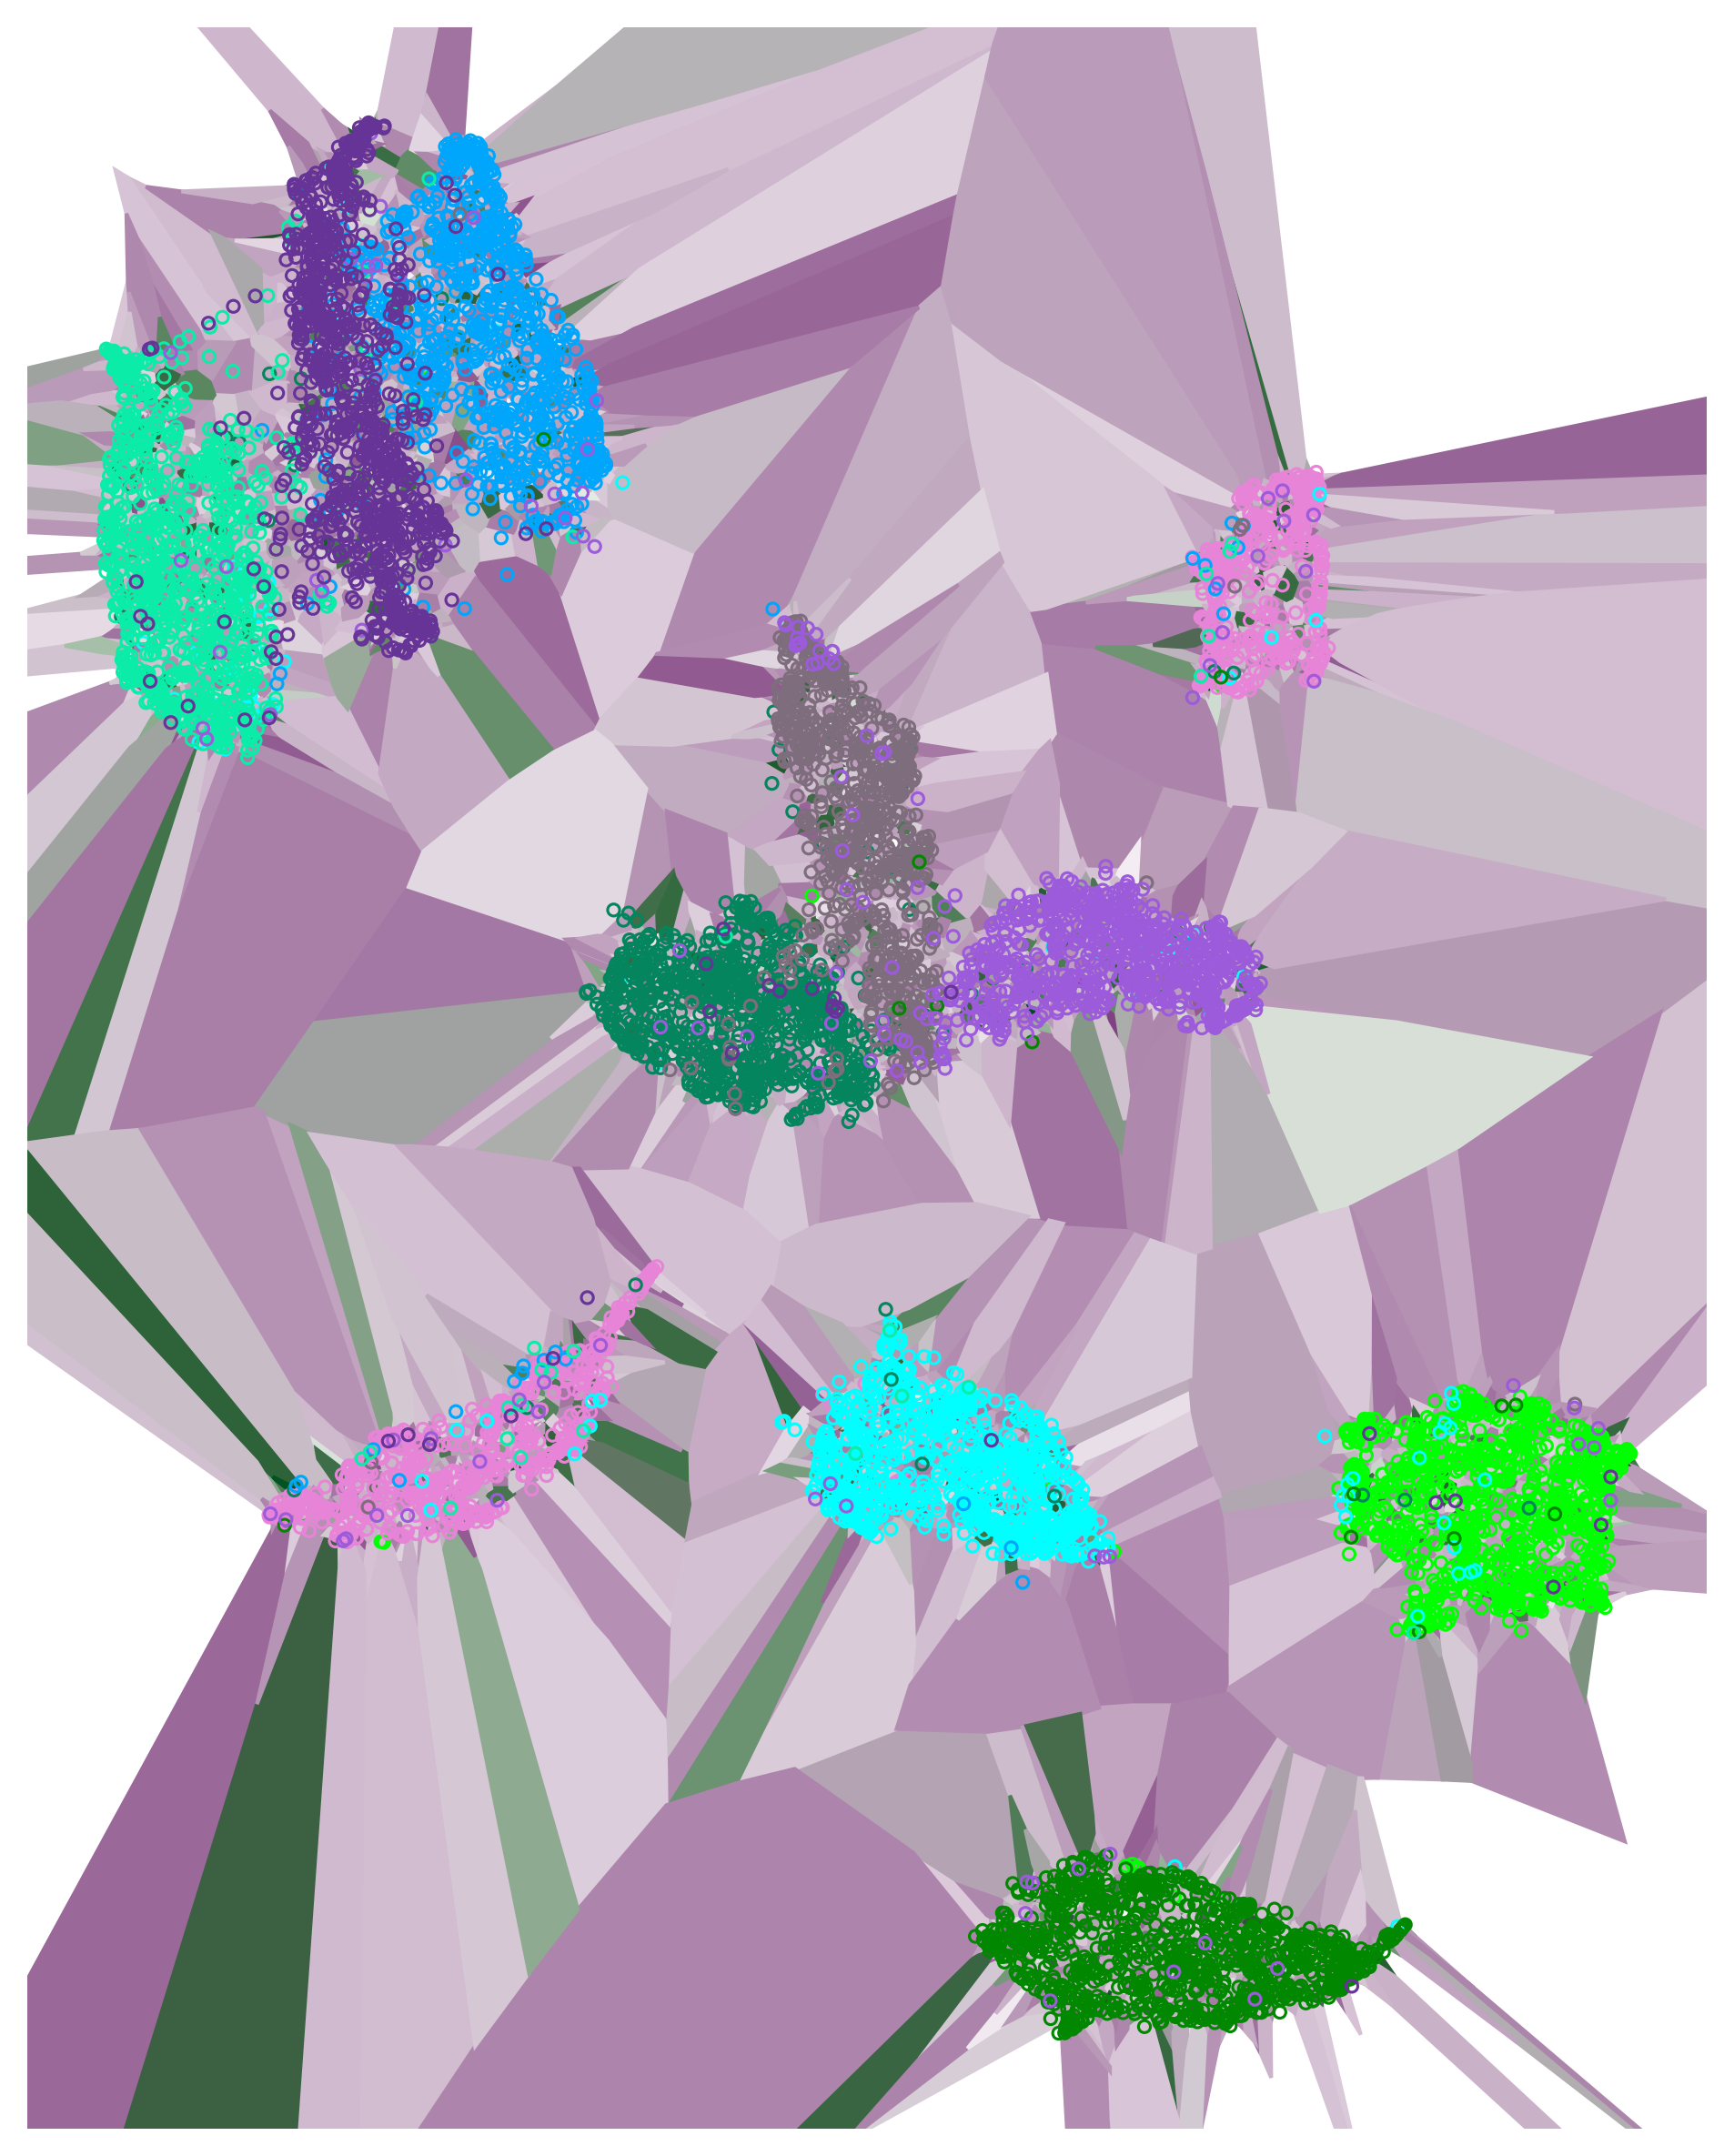

In [16]:
visualizer.plot_checkviz_custom_color(low_dm_emb, cca, nlm,  color_list= colormap, class_label=class_label, filename = f"checkvis_cca_nlm_{dataset}_true_label_{method}", data_point_size = data_point_size, output_path=output_plot_folder, dpi=dpi, save_format=save_format)


## Distortion Cue Visualization

Visualize the geometric cues derived from the original high-dimensional space to highlight projection distortions and facilitate interpretation of the embedding.

In [17]:
intensity_interp_cordinates = utility.load_numpy_array(output_folder, "intensity_interp_cordinates", dataset, ext="npy")

In [18]:
visualizer.plot_analysis_custom_color(
            low_dm_emb, 
            class_label,
             intensity_interp_cordinates, 

             show_all_edges=False,
             k_edges_per_cluster=3,
             edge_selection_mode="shortest",  #   longest, shortest
             
            bscatter_plot= bscatter_plot, 
            color_list = colormap,
            figsize=figsize, data_point_size= data_point_size, linewidths= linewidths, filename= f"delaunay_hd_edge_lengths_{dataset}_true_label_{method}",
             output_path=output_plot_folder, dpi=dpi, save_format=save_format

        )

In [19]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def save_conceptual_colorbar(output_path=".", colormap="hot", filename="distance_colorbar"):

    cmap = mpl.colormaps.get_cmap(colormap)
    norm = mpl.colors.Normalize(vmin=0, vmax=1)

    # thinner figure
    fig, ax = plt.subplots(figsize=(0.6, 4))

    cbar = mpl.colorbar.ColorbarBase(
        ax,
        cmap=cmap,
        norm=norm,
        orientation="vertical"
    )

    # remove ticks
    cbar.set_ticks([])

    # move labels closer to bar
    cbar.ax.text(
    0.5, 1.02, "far",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes
    )

    cbar.ax.text(
        0.5, -0.02, "near",
        ha="center",
        va="top",
        transform=cbar.ax.transAxes
    )
    cbar.outline.set_visible(False)

    plt.savefig(f"{output_path}/{filename}.png", bbox_inches="tight", dpi=300)
    # plt.show()
    plt.close()

In [20]:
save_conceptual_colorbar(output_plot_folder)

## 7. Sensitivity Analysis Figures (Suplementary Material Results)

Generate the figures illustrating the robustness of the proposed methodology under increasing perturbation levels, including edge preservation and neighborhood stability.

In [21]:
perturbation_levels = cfg.PERTURBATION_LEVELS

# Note:
Before running the following script run the notebook **sensitivity_and_ranks_shift_analysis.ipynb**

In [22]:
for perp in perturbation_levels:

    print(f"processing pertubation {perp}")
    file_path = f"{output_folder}/intensity_interp_cordinates_{dataset}_{perp}.npy"
    low_dm_emb_file_path = f"{output_folder}/embedding_{dataset}_{perp}.npy"
    

    intensity_interp_cordinates = np.load(file_path)
    low_dm_emb = np.load(low_dm_emb_file_path)

    visualizer.plot_analysis_custom_color(
            low_dm_emb, 
            class_label,
             intensity_interp_cordinates, 
            #  edges_short, edges_short_lenght, 

             show_all_edges=False,
             k_edges_per_cluster=3,
             edge_selection_mode="shortest",  #   longest, shortest
             
            bscatter_plot= bscatter_plot, 
            color_list = colormap,
            figsize=figsize, data_point_size= data_point_size, linewidths= linewidths, filename= f"delaunay_hd_edge_lengths_{dataset}_true_label_{method}_{perp}",
             output_path=output_plot_folder, dpi=dpi, save_format=save_format

        )

processing pertubation 0.0


FileNotFoundError: [Errno 2] No such file or directory: 'results/mnist/umap_perp_10_plots/intensity_interp_cordinates_mnist_0.0.npy'